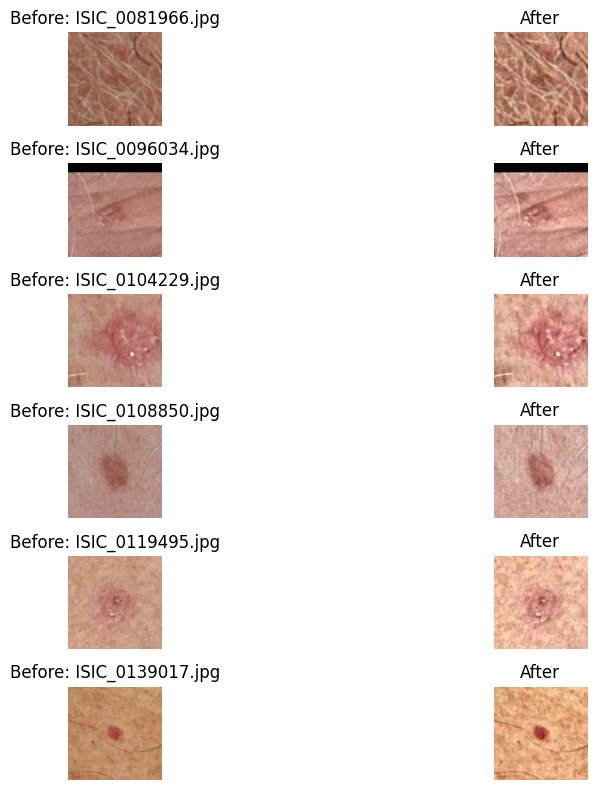

In [17]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ========== PATHS ==========
before_folder = r"C:\Users\Xena\OneDrive\Documents\DAU\Advance Image Processing\Skin_Cancer_Detection\data\final_subset_images"
after_folder = r"C:\Users\Xena\OneDrive\Documents\DAU\Advance Image Processing\Skin_Cancer_Detection\data\preprocessed_images"

# pick a few samples
sample_images = os.listdir(before_folder)[:6]

# ========== METRIC FUNCTIONS ==========

def calculate_sharpness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_noise(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray)

def calculate_brightness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

def calculate_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.std()

# ========== VISUAL COMPARISON ==========

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(sample_images):
    before = cv2.imread(os.path.join(before_folder, img_name))
    after = cv2.imread(os.path.join(after_folder, img_name))

    before = cv2.cvtColor(before, cv2.COLOR_BGR2RGB)
    after = cv2.cvtColor(after, cv2.COLOR_BGR2RGB)

    # before
    plt.subplot(len(sample_images), 2, 2*i + 1)
    plt.imshow(before)
    plt.title(f"Before: {img_name}")
    plt.axis('off')

    # after
    plt.subplot(len(sample_images), 2, 2*i + 2)
    plt.imshow(after)
    plt.title("After")
    plt.axis('off')

plt.tight_layout()
plt.show()

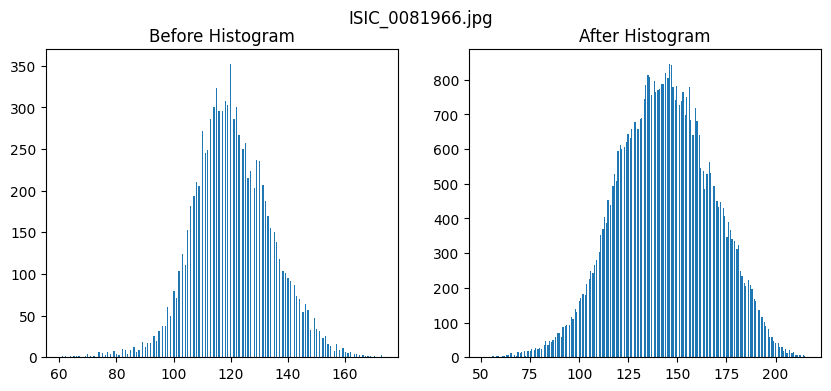

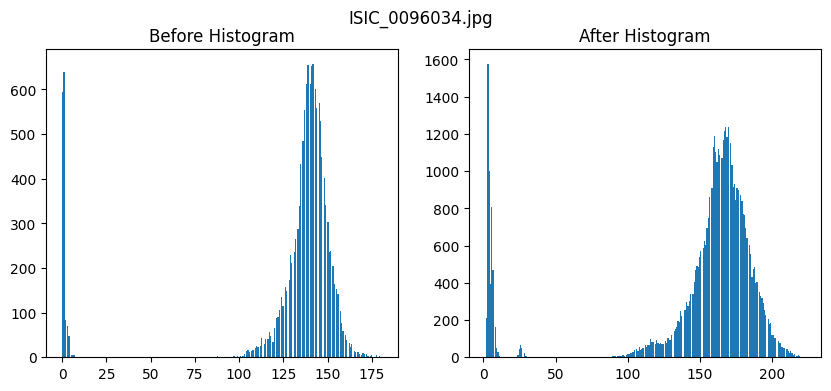

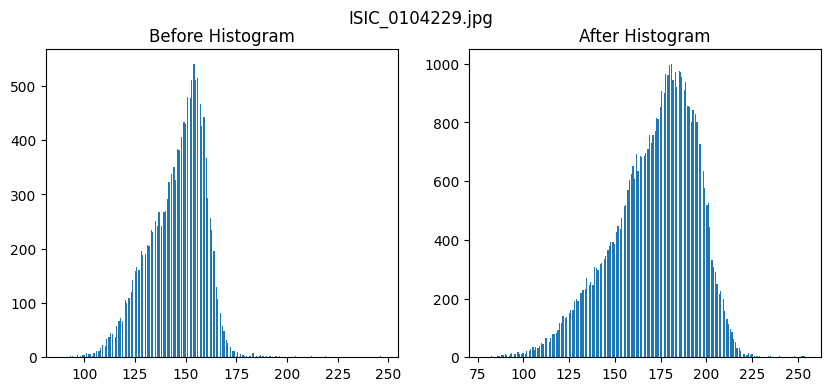

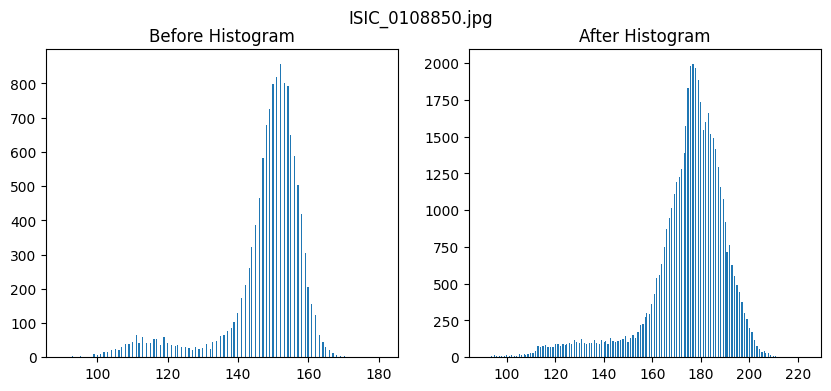

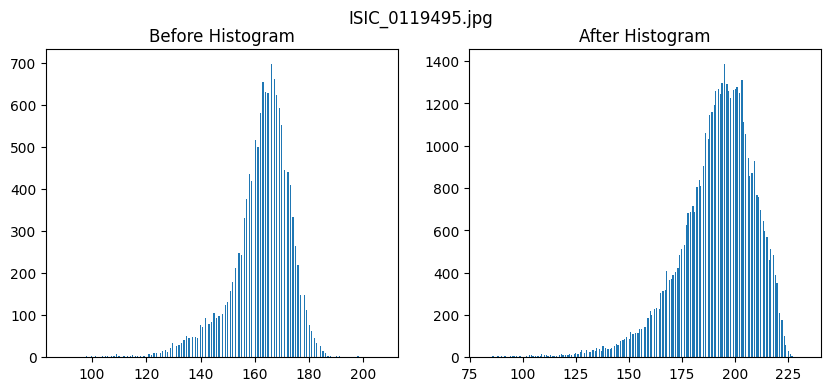

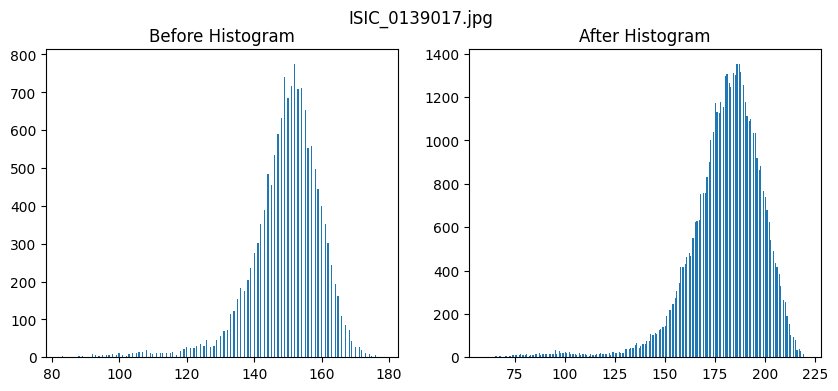

In [18]:
for img_name in sample_images:
    before = cv2.imread(os.path.join(before_folder, img_name))
    after = cv2.imread(os.path.join(after_folder, img_name))

    before_gray = cv2.cvtColor(before, cv2.COLOR_BGR2GRAY)
    after_gray = cv2.cvtColor(after, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(before_gray.ravel(), bins=256)
    plt.title("Before Histogram")

    plt.subplot(1,2,2)
    plt.hist(after_gray.ravel(), bins=256)
    plt.title("After Histogram")

    plt.suptitle(img_name)
    plt.show()

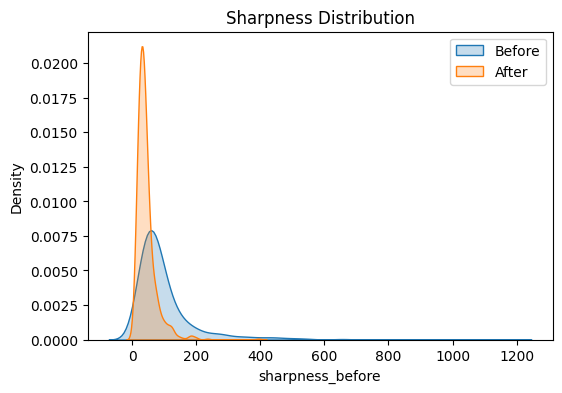

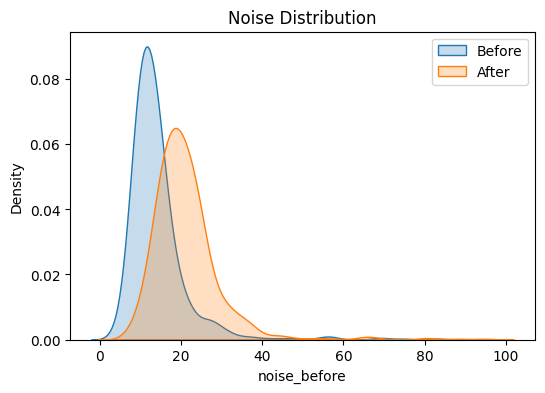

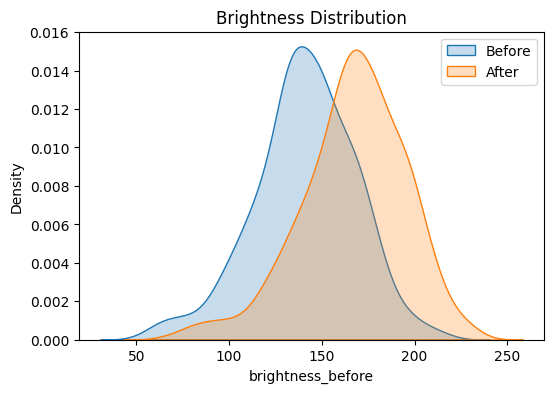

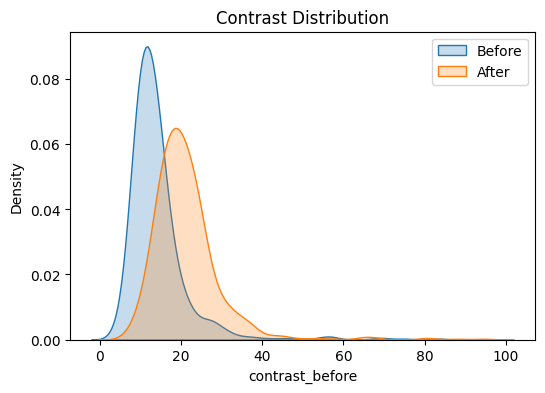

In [19]:
results = []

for img_name in os.listdir(before_folder):
    before = cv2.imread(os.path.join(before_folder, img_name))
    after = cv2.imread(os.path.join(after_folder, img_name))

    if before is None or after is None:
        continue

    data = {
        "image": img_name,

        "sharpness_before": calculate_sharpness(before),
        "sharpness_after": calculate_sharpness(after),

        "noise_before": calculate_noise(before),
        "noise_after": calculate_noise(after),

        "brightness_before": calculate_brightness(before),
        "brightness_after": calculate_brightness(after),

        "contrast_before": calculate_contrast(before),
        "contrast_after": calculate_contrast(after),
    }

    results.append(data)

import pandas as pd
df = pd.DataFrame(results)

metrics = ["sharpness", "noise", "brightness", "contrast"]

for metric in metrics:
    plt.figure(figsize=(6,4))

    sns.kdeplot(df[f"{metric}_before"], label="Before", fill=True)
    sns.kdeplot(df[f"{metric}_after"], label="After", fill=True)

    plt.title(f"{metric.capitalize()} Distribution")
    plt.legend()
    plt.show()

In [20]:
summary = pd.DataFrame({
    "Metric": ["Sharpness", "Noise", "Brightness", "Contrast"],
    "Before": [
        df["sharpness_before"].mean(),
        df["noise_before"].mean(),
        df["brightness_before"].mean(),
        df["contrast_before"].mean()
    ],
    "After": [
        df["sharpness_after"].mean(),
        df["noise_after"].mean(),
        df["brightness_after"].mean(),
        df["contrast_after"].mean()
    ]
})

print(summary)

       Metric      Before       After
0   Sharpness   99.615650   43.156430
1       Noise   14.163882   21.269662
2  Brightness  140.824097  166.655630
3    Contrast   14.163882   21.269662
